# Task 2.2 — Fine-Tuning DeepSeek-R1 for Sentiment Classification

QLoRA fine-tune `deepseek-ai/DeepSeek-R1-Distill-Qwen-14B` on the 4,000-sample
training set from Task 2.1.

| | |
|---|---|
| **Input** | `data/sft_train.jsonl` — 4,000 training samples |
| **Base Model** | `deepseek-ai/DeepSeek-R1-Distill-Qwen-14B` |
| **Method** | QLoRA (4-bit quantization + LoRA adapters) |
| **Output** | `models/sentiment_lora/` — LoRA adapter weights |

> **Requires GPU**: DGX A100 40GB on ACCRE.

## Step 1: Imports & Configuration

In [1]:
import json
import logging
import sys
from pathlib import Path

import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset as TorchDataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    Trainer,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

# ── Paths ────────────────────────────────────────────────────────────────
_cwd = Path.cwd()
TRAIN_DATA_PATH = _cwd / "data" / "sft_train.jsonl"
OUTPUT_DIR = _cwd / "models" / "sentiment_lora"
CHECKPOINTS_DIR = _cwd / "models" / "checkpoints"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Model ───────────────────────────────────────────────────────────────
MODEL_NAME = "deepseek-ai/DeepSeek-R1-Distill-Qwen-14B"

# ── QLoRA Config ──────────────────────────────────────────────────────
LORA_R = 64
LORA_ALPHA = 128
LORA_DROPOUT = 0.05
LORA_TARGET_MODULES = [
    "q_proj", "k_proj", "v_proj", "o_proj",
    "gate_proj", "up_proj", "down_proj",
]

# ── Training Hyperparams ──────────────────────────────────────────────
NUM_EPOCHS = 3
BATCH_SIZE = 4
GRAD_ACCUM_STEPS = 4  # effective batch = 4 * 4 = 16
LEARNING_RATE = 2e-4
LR_SCHEDULER = "cosine"
WARMUP_RATIO = 0.05
MAX_SEQ_LENGTH = 2048
LOGGING_STEPS = 10
SAVE_STRATEGY = "epoch"

# ── Logging ───────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-7s | %(message)s",
    datefmt="%H:%M:%S",
    handlers=[logging.StreamHandler(sys.stdout)],
    force=True,
)
log = logging.getLogger("task_2_2")

print(f"Train data:       {TRAIN_DATA_PATH} (exists={TRAIN_DATA_PATH.exists()})")
print(f"Output dir:       {OUTPUT_DIR}")
print(f"Model:            {MODEL_NAME}")
print(f"LoRA rank:        {LORA_R}, alpha: {LORA_ALPHA}")
print(f"Epochs:           {NUM_EPOCHS}")
print(f"Effective batch:  {BATCH_SIZE * GRAD_ACCUM_STEPS}")
print(f"Learning rate:    {LEARNING_RATE}")
print(f"Max seq length:   {MAX_SEQ_LENGTH}")
print(f"GPU:              {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
print(f"GPU memory:       {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB" if torch.cuda.is_available() else "")

Train data:       /panfs/accrepfs.vampire/home/sivakur/asset/fillings/roshan/Actual_code/task_2/data/sft_train.jsonl (exists=True)
Output dir:       /panfs/accrepfs.vampire/home/sivakur/asset/fillings/roshan/Actual_code/task_2/models/sentiment_lora
Model:            deepseek-ai/DeepSeek-R1-Distill-Qwen-14B
LoRA rank:        64, alpha: 128
Epochs:           3
Effective batch:  16
Learning rate:    0.0002
Max seq length:   2048
GPU:              NVIDIA A100-SXM4-40GB
GPU memory:       42.4 GB


## Step 2: Load Base Model (4-bit Quantized)

In [2]:
# 4-bit quantization config for QLoRA
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

print("Loading base model in 4-bit...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map={"": 0},              # force all layers on GPU 0 (no CPU offload)
    torch_dtype=torch.bfloat16,
    trust_remote_code=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

# Ensure pad token is set
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    model.config.pad_token_id = tokenizer.eos_token_id

# Prepare model for k-bit training (freeze base, enable gradient checkpointing)
model = prepare_model_for_kbit_training(model)

print(f"Model loaded: {MODEL_NAME}")
print(f"Model dtype: {model.dtype}")
print(f"Tokenizer vocab size: {len(tokenizer)}")
print(f"Pad token: '{tokenizer.pad_token}' (id={tokenizer.pad_token_id})")

Loading base model in 4-bit...
14:08:39 | INFO    | HTTP Request: HEAD https://huggingface.co/deepseek-ai/DeepSeek-R1-Distill-Qwen-14B/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
14:08:39 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/deepseek-ai/DeepSeek-R1-Distill-Qwen-14B/1df8507178afcc1bef68cd8c393f61a886323761/config.json "HTTP/1.1 200 OK"


`torch_dtype` is deprecated! Use `dtype` instead!


14:08:39 | INFO    | HTTP Request: HEAD https://huggingface.co/deepseek-ai/DeepSeek-R1-Distill-Qwen-14B/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
14:08:39 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/deepseek-ai/DeepSeek-R1-Distill-Qwen-14B/1df8507178afcc1bef68cd8c393f61a886323761/config.json "HTTP/1.1 200 OK"


Loading weights:   0%|          | 0/579 [00:00<?, ?it/s]

14:10:17 | INFO    | HTTP Request: HEAD https://huggingface.co/deepseek-ai/DeepSeek-R1-Distill-Qwen-14B/resolve/main/generation_config.json "HTTP/1.1 307 Temporary Redirect"
14:10:17 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/deepseek-ai/DeepSeek-R1-Distill-Qwen-14B/1df8507178afcc1bef68cd8c393f61a886323761/generation_config.json "HTTP/1.1 200 OK"
14:10:17 | INFO    | HTTP Request: HEAD https://huggingface.co/deepseek-ai/DeepSeek-R1-Distill-Qwen-14B/resolve/main/custom_generate/generate.py "HTTP/1.1 404 Not Found"


14:10:17 | WARNING | Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
14:10:17 | INFO    | HTTP Request: HEAD https://huggingface.co/deepseek-ai/DeepSeek-R1-Distill-Qwen-14B/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
14:10:17 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/deepseek-ai/DeepSeek-R1-Distill-Qwen-14B/1df8507178afcc1bef68cd8c393f61a886323761/config.json "HTTP/1.1 200 OK"
14:10:17 | INFO    | HTTP Request: HEAD https://huggingface.co/deepseek-ai/DeepSeek-R1-Distill-Qwen-14B/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
14:10:18 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/deepseek-ai/DeepSeek-R1-Distill-Qwen-14B/1df8507178afcc1bef68cd8c393f61a886323761/tokenizer_config.json "HTTP/1.1 200 OK"
14:10:18 | INFO    | HTTP Request: HEAD https://huggingface.co/deepseek-ai/DeepSeek-R1-Distill-

## Step 3: Apply LoRA Adapters

In [3]:
lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGET_MODULES,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)

# Print trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
trainable_pct = trainable_params / total_params * 100

print(f"LoRA config:")
print(f"  Rank: {LORA_R}")
print(f"  Alpha: {LORA_ALPHA}")
print(f"  Dropout: {LORA_DROPOUT}")
print(f"  Target modules: {LORA_TARGET_MODULES}")
print(f"\nParameter counts:")
print(f"  Trainable: {trainable_params:,} ({trainable_pct:.2f}%)")
print(f"  Total:     {total_params:,}")
model.print_trainable_parameters()

LoRA config:
  Rank: 64
  Alpha: 128
  Dropout: 0.05
  Target modules: ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']

Parameter counts:
  Trainable: 275,251,200 (3.26%)
  Total:     8,439,256,064
trainable params: 275,251,200 || all params: 15,045,284,864 || trainable%: 1.8295


## Step 4: Load Training Data

In [4]:
# ── Custom PyTorch Dataset (no HF datasets dependency) ──────────────────

class ChatSFTDataset(TorchDataset):
    """Tokenizes chat-format JSONL records for causal LM fine-tuning.
    
    Only computes loss on assistant response tokens — prompt tokens are
    masked with -100 in labels so the model learns the output format.
    """

    def __init__(self, records: list[dict], tokenizer, max_length: int):
        self.records = records
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        messages = self.records[idx]["messages"]

        # 1. Tokenize the FULL conversation (system + user + assistant)
        full_text = self.tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False,
        )
        full_encoded = self.tokenizer(
            full_text,
            max_length=self.max_length,
            truncation=True,
            add_special_tokens=False,
        )
        input_ids = full_encoded["input_ids"]

        # 2. Tokenize the PROMPT only (system + user, no assistant)
        prompt_text = self.tokenizer.apply_chat_template(
            messages[:2],  # system + user only
            tokenize=False,
            add_generation_prompt=True,
        )
        prompt_encoded = self.tokenizer(
            prompt_text,
            add_special_tokens=False,
        )
        prompt_len = len(prompt_encoded["input_ids"])

        # 3. Build labels: -100 for prompt tokens, real IDs for assistant tokens
        labels = [-100] * prompt_len + input_ids[prompt_len:]

        # Ensure labels and input_ids are same length
        labels = labels[:len(input_ids)]

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.ones(len(input_ids), dtype=torch.long),
            "labels": torch.tensor(labels, dtype=torch.long),
        }


def collate_fn(batch):
    """Pad batch to max length, set padding positions to -100 in labels."""
    max_len = max(item["input_ids"].size(0) for item in batch)
    pad_id = tokenizer.pad_token_id

    input_ids_padded = []
    attention_mask_padded = []
    labels_padded = []

    for item in batch:
        seq_len = item["input_ids"].size(0)
        pad_len = max_len - seq_len
        # Left-pad for causal LM
        input_ids_padded.append(
            torch.cat([torch.full((pad_len,), pad_id, dtype=torch.long), item["input_ids"]])
        )
        attention_mask_padded.append(
            torch.cat([torch.zeros(pad_len, dtype=torch.long), item["attention_mask"]])
        )
        labels_padded.append(
            torch.cat([torch.full((pad_len,), -100, dtype=torch.long), item["labels"]])
        )

    return {
        "input_ids": torch.stack(input_ids_padded),
        "attention_mask": torch.stack(attention_mask_padded),
        "labels": torch.stack(labels_padded),
    }


# ── Load JSONL ──────────────────────────────────────────────────────────
train_records = []
with open(TRAIN_DATA_PATH) as f:
    for line in f:
        train_records.append(json.loads(line.strip()))

print(f"Loaded {len(train_records)} training records")

# Build dataset
train_dataset = ChatSFTDataset(train_records, tokenizer, MAX_SEQ_LENGTH)

print(f"Dataset size: {len(train_dataset)}")
print(f"\nSample messages[0] roles: {[m['role'] for m in train_records[0]['messages']]}")

# Verify tokenization + label masking
sample_item = train_dataset[0]
n_total = sample_item["labels"].size(0)
n_masked = (sample_item["labels"] == -100).sum().item()
n_trained = n_total - n_masked

print(f"\nSample item:")
print(f"  Total tokens:    {n_total}")
print(f"  Prompt (masked): {n_masked} tokens — loss NOT computed")
print(f"  Response:        {n_trained} tokens — loss computed here")

# Show the assistant response tokens
response_ids = sample_item["labels"][sample_item["labels"] != -100].tolist()
response_text = tokenizer.decode(response_ids, skip_special_tokens=True)
print(f"\n  Response text: {response_text}")

Loaded 4000 training records
Dataset size: 4000

Sample messages[0] roles: ['system', 'user', 'assistant']

Sample item:
  Total tokens:    253
  Prompt (masked): 218 tokens — loss NOT computed
  Response:        35 tokens — loss computed here

  Response text: ": "neutral", "rationale": "Geopolitical risks exist but are not expected to significantly impact the company's operations.", "confidence": 0.6}


## Step 5: Training Arguments

In [5]:
training_args = TrainingArguments(
    output_dir=str(CHECKPOINTS_DIR),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=2,          # reduced from 4 to avoid OOM on A100 40GB
    gradient_accumulation_steps=8,          # increased to keep effective batch = 16
    learning_rate=LEARNING_RATE,
    lr_scheduler_type=LR_SCHEDULER,
    warmup_ratio=WARMUP_RATIO,
    bf16=True,
    logging_steps=LOGGING_STEPS,
    save_strategy=SAVE_STRATEGY,
    optim="paged_adamw_8bit",
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    max_grad_norm=0.3,
    report_to="none",
    remove_unused_columns=False,
    seed=42,
)

n_samples = len(train_dataset)
eff_batch = 2 * 8
total_steps = (n_samples // eff_batch) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

print(f"Training config:")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Batch size: 2 × 8 grad accum = {eff_batch} effective")
print(f"  Samples: {n_samples}")
print(f"  Total steps: ~{total_steps}")
print(f"  Warmup steps: ~{warmup_steps}")
print(f"  Learning rate: {LEARNING_RATE} with {LR_SCHEDULER} scheduler")
print(f"  Optimizer: paged_adamw_8bit")
print(f"  Precision: bf16")
print(f"  Gradient checkpointing: enabled")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training config:
  Epochs: 3
  Batch size: 2 × 8 grad accum = 16 effective
  Samples: 4000
  Total steps: ~750
  Warmup steps: ~37
  Learning rate: 0.0002 with cosine scheduler
  Optimizer: paged_adamw_8bit
  Precision: bf16
  Gradient checkpointing: enabled


## Step 6: Train

In [6]:
# Ensure PEFT model preserves device_map so Trainer doesn't try to .to(device) again
if not hasattr(model, "hf_device_map"):
    model.hf_device_map = {"": 0}

trainer = Trainer(
    model=model,
    processing_class=tokenizer,
    train_dataset=train_dataset,
    args=training_args,
    data_collator=collate_fn,
)

print("Starting training...")
print(f"{'='*60}")
train_result = trainer.train()
print(f"{'='*60}")
print(f"Training complete!")
print(f"  Total steps: {train_result.global_step}")
print(f"  Training loss: {train_result.training_loss:.4f}")
print(f"  Runtime: {train_result.metrics.get('train_runtime', 0):.0f}s")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 151646, 'pad_token_id': 151643}.


Starting training...


Step,Training Loss
10,0.661919
20,0.443698
30,0.368910
40,0.363402
50,0.382215
60,0.394053
70,0.372915
80,0.401865
90,0.376881
100,0.393654


14:37:45 | INFO    | HTTP Request: HEAD https://huggingface.co/deepseek-ai/DeepSeek-R1-Distill-Qwen-14B/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
14:37:45 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/deepseek-ai/DeepSeek-R1-Distill-Qwen-14B/1df8507178afcc1bef68cd8c393f61a886323761/config.json "HTTP/1.1 200 OK"
14:37:45 | INFO    | HTTP Request: HEAD https://huggingface.co/deepseek-ai/DeepSeek-R1-Distill-Qwen-14B/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
14:37:45 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/deepseek-ai/DeepSeek-R1-Distill-Qwen-14B/1df8507178afcc1bef68cd8c393f61a886323761/config.json "HTTP/1.1 200 OK"
15:05:04 | INFO    | HTTP Request: HEAD https://huggingface.co/deepseek-ai/DeepSeek-R1-Distill-Qwen-14B/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
15:05:04 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/deepseek-ai/DeepSeek-R1

## Step 7: Save LoRA Adapter

In [7]:
# Save the LoRA adapter weights (NOT the full model — just the ~200MB adapter)
model.save_pretrained(str(OUTPUT_DIR))
tokenizer.save_pretrained(str(OUTPUT_DIR))

# Verify files saved
saved_files = list(OUTPUT_DIR.iterdir())
total_size_mb = sum(f.stat().st_size for f in saved_files if f.is_file()) / (1024 * 1024)

print(f"LoRA adapter saved to: {OUTPUT_DIR}")
print(f"Files:")
for f in sorted(saved_files):
    if f.is_file():
        size_mb = f.stat().st_size / (1024 * 1024)
        print(f"  {f.name} ({size_mb:.1f} MB)")
print(f"Total: {total_size_mb:.1f} MB")

15:32:27 | INFO    | HTTP Request: HEAD https://huggingface.co/deepseek-ai/DeepSeek-R1-Distill-Qwen-14B/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
15:32:27 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/deepseek-ai/DeepSeek-R1-Distill-Qwen-14B/1df8507178afcc1bef68cd8c393f61a886323761/config.json "HTTP/1.1 200 OK"
15:32:27 | INFO    | HTTP Request: HEAD https://huggingface.co/deepseek-ai/DeepSeek-R1-Distill-Qwen-14B/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
15:32:27 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/deepseek-ai/DeepSeek-R1-Distill-Qwen-14B/1df8507178afcc1bef68cd8c393f61a886323761/config.json "HTTP/1.1 200 OK"
LoRA adapter saved to: /panfs/accrepfs.vampire/home/sivakur/asset/fillings/roshan/Actual_code/task_2/models/sentiment_lora
Files:
  README.md (0.0 MB)
  adapter_config.json (0.0 MB)
  adapter_model.safetensors (1050.1 MB)
  chat_template.jinja (0.0 MB)
  tokenizer.json (10.

## Step 8: Training Curves

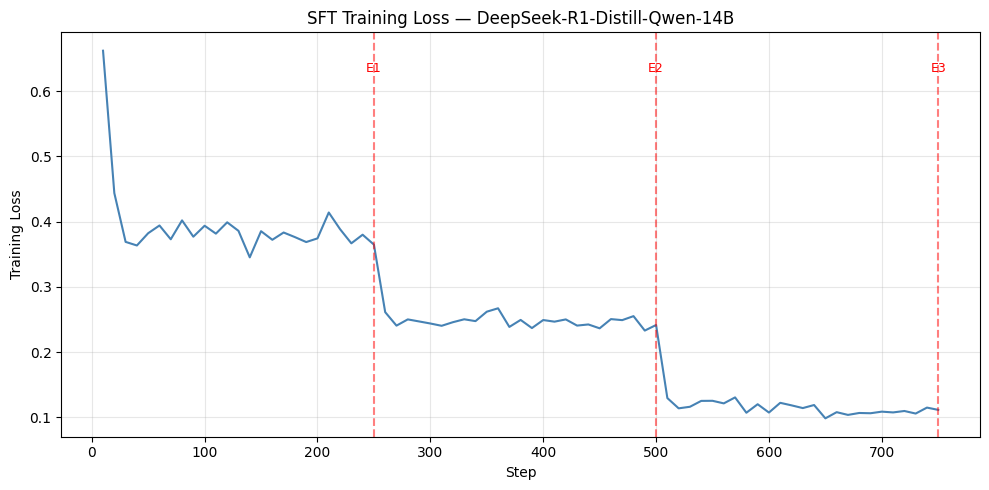


Loss summary:
  Start: 0.6619
  End:   0.1114
  Min:   0.0985 (step 650)


In [8]:
# Extract training loss from trainer log history
log_history = trainer.state.log_history

steps = []
losses = []
for entry in log_history:
    if "loss" in entry and "step" in entry:
        steps.append(entry["step"])
        losses.append(entry["loss"])

if losses:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(steps, losses, linewidth=1.5, color="steelblue")
    ax.set_xlabel("Step")
    ax.set_ylabel("Training Loss")
    ax.set_title(f"SFT Training Loss — {MODEL_NAME.split('/')[-1]}")
    ax.grid(True, alpha=0.3)

    # Mark epoch boundaries
    steps_per_epoch = len(train_dataset) // (BATCH_SIZE * GRAD_ACCUM_STEPS)
    for epoch in range(1, NUM_EPOCHS + 1):
        epoch_step = epoch * steps_per_epoch
        ax.axvline(x=epoch_step, color="red", linestyle="--", alpha=0.5, label=f"Epoch {epoch}" if epoch == 1 else "")
        ax.text(epoch_step, max(losses) * 0.95, f"E{epoch}", ha="center", fontsize=9, color="red")

    plt.tight_layout()
    plt.show()

    print(f"\nLoss summary:")
    print(f"  Start: {losses[0]:.4f}")
    print(f"  End:   {losses[-1]:.4f}")
    print(f"  Min:   {min(losses):.4f} (step {steps[losses.index(min(losses))]})")
else:
    print("No loss data found in training logs.")

## Step 9: Quick Sanity Check

Run a single inference to verify the fine-tuned model produces valid JSON sentiment output.

In [10]:
# Quick sanity check — run one inference
# Disable gradient checkpointing for inference
model.eval()
model.gradient_checkpointing_disable()

test_messages = train_records[0]["messages"][:2]  # system + user only (no assistant)

input_text = tokenizer.apply_chat_template(
    test_messages,
    tokenize=False,
    add_generation_prompt=True,
)
# DeepSeek-R1 wants to <think> first — skip it with empty think block
input_text += "<think>\n</think>\n"

inputs = tokenizer(input_text, return_tensors="pt", add_special_tokens=False).to(model.device)

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=256,
        temperature=0.1,
        do_sample=True,
        pad_token_id=tokenizer.pad_token_id,
    )

# Decode only the generated portion
generated = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

print("Sanity check — SFT model inference:")
print(f"{'='*60}")
print(f"Generated output:")
print(generated)
print(f"{'='*60}")

# Try to parse as JSON
try:
    parsed = json.loads(generated.strip())
    print(f"\nParsed JSON: {json.dumps(parsed, indent=2)}")
    print(f"Valid JSON: YES")
    if "label" in parsed:
        print(f"Label: {parsed['label']}")
except json.JSONDecodeError:
    print(f"\nValid JSON: NO — may need more training or prompt tuning")

# Show expected output for comparison
expected = train_records[0]["messages"][2]["content"]
print(f"\nExpected: {expected}")

Sanity check — SFT model inference:
Generated output:
{
  "sentiment": "neutral",
  "rationale": "Geopolitical risks exist but are not expected to significantly impact the company's operations.",
  "confidence": 0.6
}

Parsed JSON: {
  "sentiment": "neutral",
  "rationale": "Geopolitical risks exist but are not expected to significantly impact the company's operations.",
  "confidence": 0.6
}
Valid JSON: YES

Expected: {"label": "neutral", "rationale": "Geopolitical risks exist but are not expected to significantly impact the company's operations.", "confidence": 0.6}
